In [34]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [35]:
# ── Rutas ─────────────────────────────────────────────────────
DATA_DIR = Path("../../datasets/raw/myotensor_proto/S01")

csv_path  = DATA_DIR / "session_20260409_233919.csv"
meta_path = DATA_DIR / "session_20260409_233919_metadata.json"

In [36]:
# ── Metadata ───────────────────────────────────────────────────
with open(meta_path) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2, ensure_ascii=False))

# ── Dataset ────────────────────────────────────────────────────
df = pd.read_csv(csv_path)
df['time_s'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1e6

print(f"\nForma: {df.shape}")
print(f"Duración (por timestamp): {df['time_s'].iloc[-1]:.2f}s")
print(f"Duración (por muestras):  {len(df)/1000:.2f}s")
df.head()

{
  "subject_id": "S01",
  "age": 28,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 26.0,
  "muscle": "FDP",
  "date": "2026-04-09T23:39:19.701765",
  "fs_hz": 1000,
  "total_samples": 222200,
  "duration_s": 222.2,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": -1.6250410958904111,
    "noise_std": 4.820683080602575,
    "onset_threshold_v": 12.837008145917315,
    "mvc_voltage_v": 302.5763748581911,
    "noise_samples": 4380,
    "mvc_samples": 2780
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260409_233919.csv"
}

Forma: (222200, 12)
Duración (por timestamp): 242.28s
Duración (por muestras):  222.20s


,timestamp_us,raw,centered,filtered,voltage_v,emg_norm,stimulus,set_id,repetition_id,restimulus,valid_flag,time_s
0,176050860,1903,66.0,18.54,1.5336,0.061274,0,1,1,0,1,0.000000
1,176051770,1905,68.0,16.14,1.5352,0.053342,0,1,1,0,1,0.000910
2,176052792,1902,65.0,13.11,1.5327,0.043328,0,1,1,0,1,0.001932
3,176053774,1903,66.0,9.08,1.5336,0.030009,0,1,1,0,1,0.002914
4,176054768,1905,68.0,6.75,1.5352,0.022308,0,1,1,0,1,0.003908


## 1 — Calidad de adquisición
Analizamos los intervalos entre timestamps para detectar gaps (paquetes UDP perdidos).

=== Calidad de adquisición ===
  Muestras grabadas:        222,200
  Intervalo medio:           1090.4 µs  (target: 1000 µs)
  Std intervalo:             5844.9 µs
  Fs efectiva:                917.1 Hz
  Gaps detectados (>1.5ms):     666
  Muestras perdidas (est.):  20,820
  Pérdida:                     8.57%

  Top 10 gaps más grandes:
    1661.1ms en t=205.84s
    1641.1ms en t=96.04s
    1221.1ms en t=186.16s
    241.1ms en t=186.80s
    221.1ms en t=184.74s
    181.1ms en t=138.02s
    101.1ms en t=98.50s
    101.1ms en t=63.48s
    81.1ms en t=56.74s
    81.1ms en t=108.74s


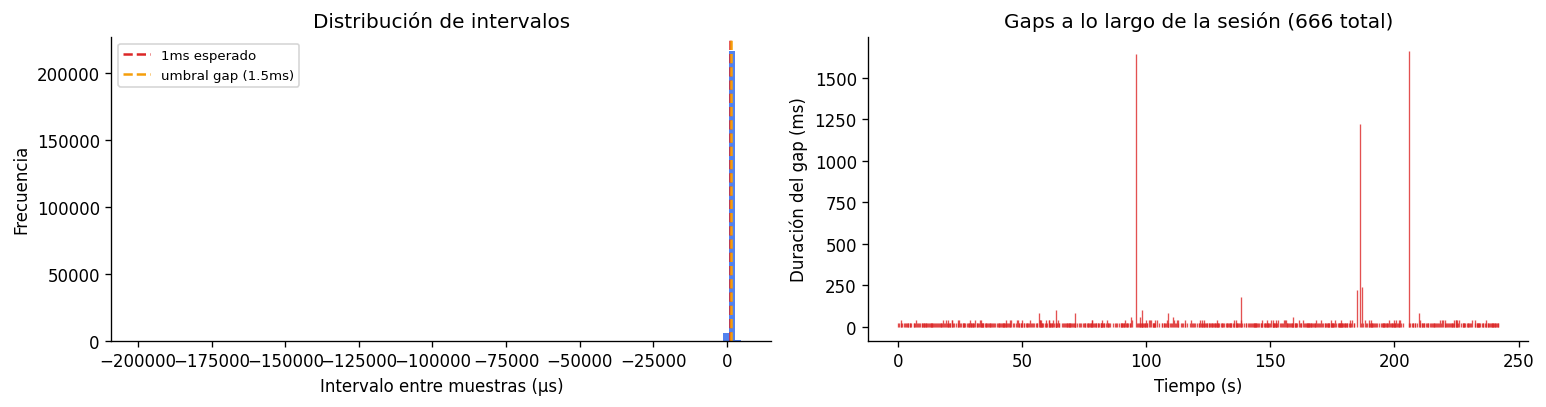

In [37]:
dt_us = df['timestamp_us'].diff().dropna()   # intervalos en µs
expected_us = 1000                            # 1ms @ 1kHz
gap_threshold_us = 1500                      # >1.5ms → muestra perdida

gaps = dt_us[dt_us > gap_threshold_us]
missing_est = int((gaps - expected_us).sum() / expected_us)
fs_efectiva = 1e6 / dt_us.mean()

print("=== Calidad de adquisición ===")
print(f"  Muestras grabadas:        {len(df):>7,}")
print(f"  Intervalo medio:          {dt_us.mean():>7.1f} µs  (target: {expected_us} µs)")
print(f"  Std intervalo:            {dt_us.std():>7.1f} µs")
print(f"  Fs efectiva:              {fs_efectiva:>7.1f} Hz")
print(f"  Gaps detectados (>{gap_threshold_us/1000:.1f}ms): {len(gaps):>7,}")
print(f"  Muestras perdidas (est.): {missing_est:>7,}")
print(f"  Pérdida:                  {missing_est/(len(df)+missing_est)*100:>7.2f}%")

print("\n  Top 10 gaps más grandes:")
for idx in gaps.nlargest(10).index:
    print(f"    {dt_us[idx]/1000:.1f}ms en t={df.loc[idx,'time_s']:.2f}s")

# ── Histograma de intervalos ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))

# Todos los intervalos
ax1.hist(dt_us.clip(upper=5000), bins=100, color='#2563eb', alpha=0.8, edgecolor='none')
ax1.axvline(expected_us, color='#dc2626', lw=1.5, ls='--', label='1ms esperado')
ax1.axvline(gap_threshold_us, color='#f59e0b', lw=1.5, ls='--', label=f'umbral gap ({gap_threshold_us/1000:.1f}ms)')
ax1.set_xlabel('Intervalo entre muestras (µs)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de intervalos')
ax1.legend(fontsize=8)

# Gaps en el tiempo
ax2.vlines(df.loc[gaps.index, 'time_s'], 0, gaps.values / 1000,
           color='#dc2626', lw=0.8, alpha=0.8)
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Duración del gap (ms)')
ax2.set_title(f'Gaps a lo largo de la sesión ({len(gaps)} total)')

plt.tight_layout()
plt.show()

## 2 — Distribución de muestras por gesto

=== Muestras por gesto (stimulus) ===
  0 — Reposo  : 84,540 muestras  (84.5s)
  1 — Palma   : 45,880 muestras  (45.9s)
  2 — Puño    : 44,300 muestras  (44.3s)
  3 — Paz     : 47,480 muestras  (47.5s)

=== Muestras por gesto (restimulus) ===
  0 — Reposo  : 222,200 muestras  (222.2s)


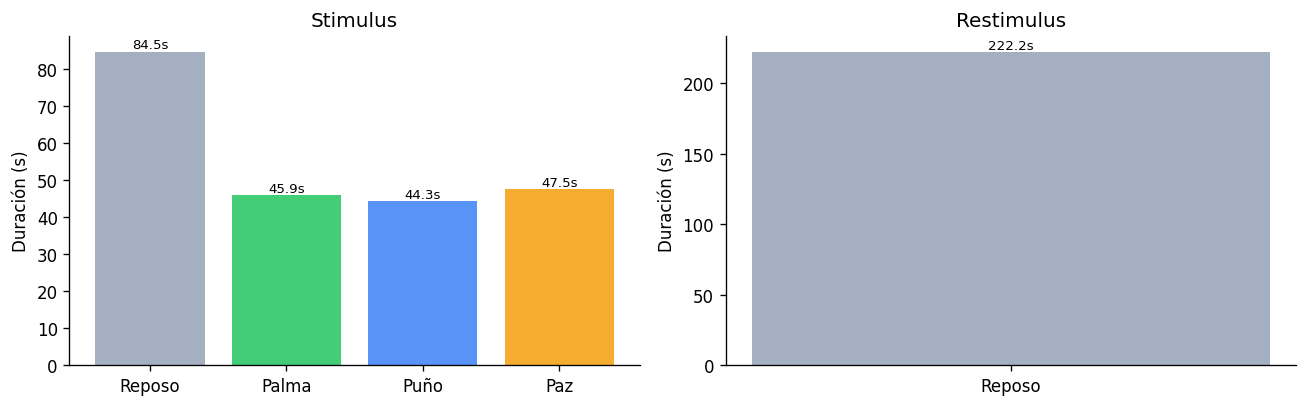

In [38]:
STIM_NAMES  = {0: 'Reposo', 1: 'Palma', 2: 'Puño', 3: 'Paz'}
STIM_COLORS = {0: '#94a3b8', 1: '#22c55e', 2: '#3b82f6', 3: '#f59e0b'}

print("=== Muestras por gesto (stimulus) ===")
for sid in sorted(df['stimulus'].unique()):
    n = (df['stimulus'] == sid).sum()
    dur = n / 1000
    print(f"  {sid} — {STIM_NAMES[sid]:<8}: {n:>6,} muestras  ({dur:.1f}s)")

print("\n=== Muestras por gesto (restimulus) ===")
for sid in sorted(df['restimulus'].unique()):
    n = (df['restimulus'] == sid).sum()
    print(f"  {sid} — {STIM_NAMES.get(sid,'Reposo'):<8}: {n:>6,} muestras  ({n/1000:.1f}s)")

# Barras
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title in zip(axes, ['stimulus', 'restimulus'], ['Stimulus', 'Restimulus']):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(
        [STIM_NAMES[i] for i in counts.index],
        counts.values / 1000,
        color=[STIM_COLORS[i] for i in counts.index],
        edgecolor='none', alpha=0.85
    )
    ax.set_ylabel('Duración (s)')
    ax.set_title(title)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{v/1000:.1f}s', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 3 — Vista general de la sesión

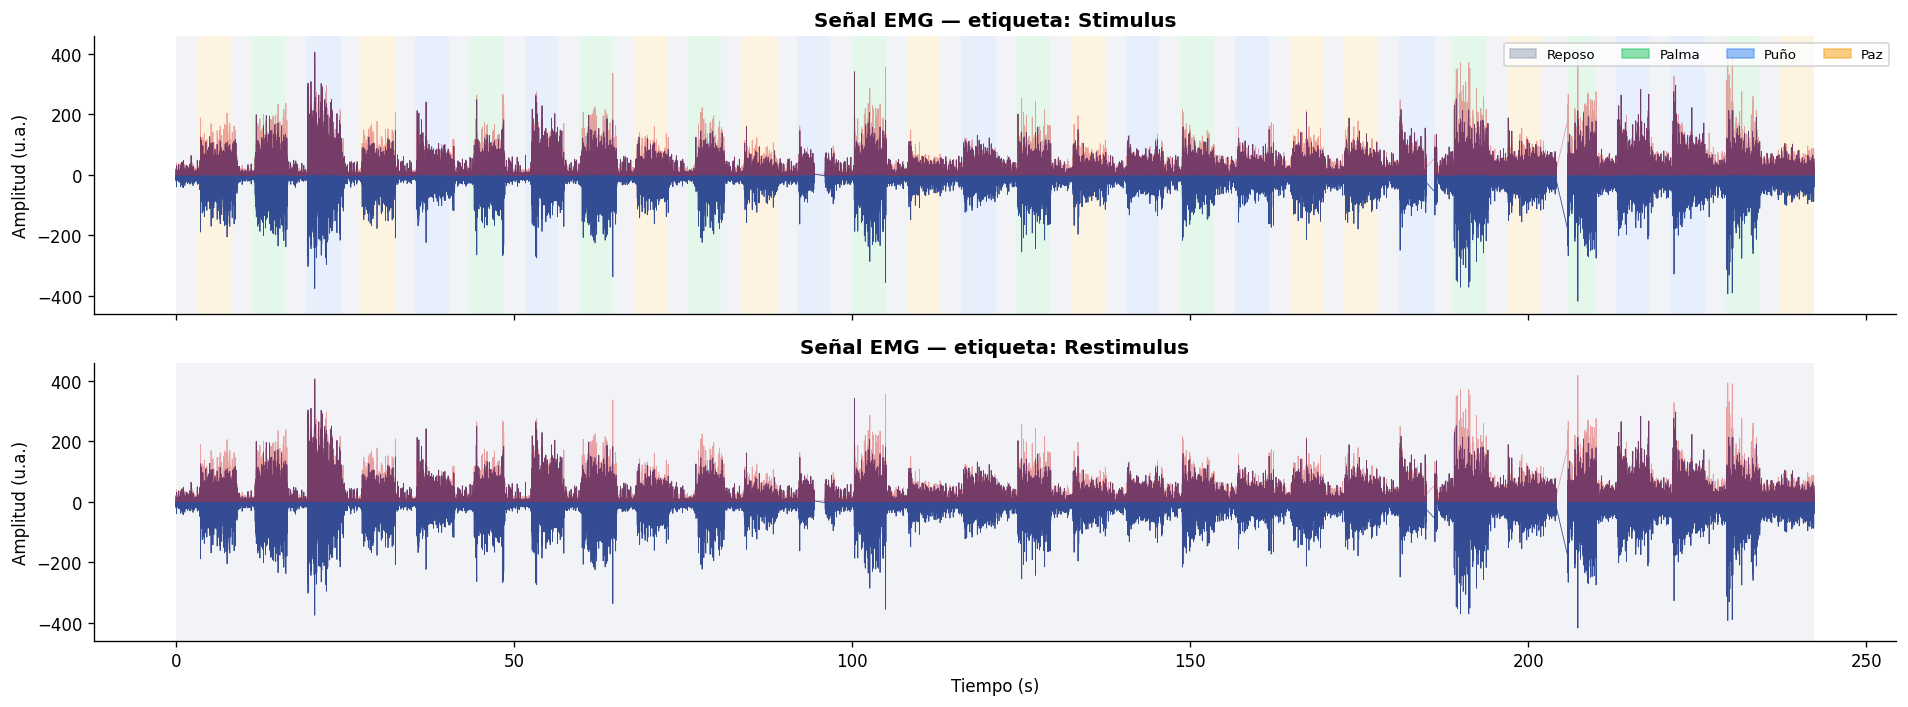

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

for ax, col, title in zip(axes, ['stimulus', 'restimulus'], ['Stimulus', 'Restimulus']):
    # Señal EMG
    ax.plot(df['time_s'], df['filtered'], color='#1e3a8a', lw=0.5, alpha=0.9)
    ax.plot(df['time_s'], df['filtered'].abs(), color='#dc2626', lw=0.5, alpha=0.4, label='|filtrado|')

    # Fondo por gesto (segmentos contiguos)
    changes = df.index[df[col] != df[col].shift()].tolist() + [df.index[-1] + 1]
    for i in range(len(changes) - 1):
        i0, i1 = changes[i], changes[i+1]
        stim = df.loc[i0, col]
        t0 = df.loc[i0, 'time_s']
        t1 = df.loc[min(i1, df.index[-1]), 'time_s']
        ax.axvspan(t0, t1, alpha=0.12, color=STIM_COLORS[stim], lw=0)

    ax.set_ylabel('Amplitud (u.a.)')
    ax.set_title(f'Señal EMG — etiqueta: {title}', fontweight='bold')

axes[-1].set_xlabel('Tiempo (s)')

# Leyenda compartida
patches = [mpatches.Patch(color=STIM_COLORS[k], alpha=0.5, label=STIM_NAMES[k])
           for k in STIM_COLORS]
axes[0].legend(handles=patches, loc='upper right', fontsize=8, ncol=4)

plt.tight_layout()
plt.show()

## 4 — Zoom: Puño rep 1 + 3s de reposo
Ventana de 8 segundos: 5s de contracción + 3s de descanso.

In [40]:
# ── Extraer segmento: puño rep 1 (5s activo + 3s reposo) ──────
puno_r1 = df[(df['stimulus'] == 2) & (df['repetition'] == 1)]

if puno_r1.empty:
    print("[!] No se encontraron datos de puño rep 1 (stimulus=2, repetition=1)")
else:
    t0_us = puno_r1['timestamp_us'].iloc[0]
    t1_us = t0_us + 8_000_000  # 8 segundos

    seg = df[(df['timestamp_us'] >= t0_us) & (df['timestamp_us'] < t1_us)].copy()
    seg['t'] = (seg['timestamp_us'] - t0_us) / 1e6

    print(f"Muestras en segmento: {len(seg)}  ({len(seg)/1000:.1f}s)")
    print(f"  stimulus=2 (puño):  {(seg['stimulus']==2).sum()} muestras")
    print(f"  stimulus=0 (reposo):{(seg['stimulus']==0).sum()} muestras")

    # ── Gráfico ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    # Fondo: activo (azul) vs reposo (gris)
    ax.axvspan(0, 5, alpha=0.10, color=STIM_COLORS[2], lw=0, label='Activo (stimulus=2)')
    ax.axvspan(5, 8, alpha=0.10, color=STIM_COLORS[0], lw=0, label='Reposo (stimulus=0)')

    # Límite stimulus vs restimulus (+250ms)
    ax.axvline(0.25, color=STIM_COLORS[2], lw=1.2, ls='--', alpha=0.7, label='Restimulus inicio (+250ms)')
    ax.axvline(5 - 0.25, color=STIM_COLORS[0], lw=1.2, ls='--', alpha=0.7, label='Restimulus fin (-250ms)')
    ax.axvline(5.0, color='#475569', lw=1, ls='-', alpha=0.5)

    # Señal
    ax.plot(seg['t'], seg['filtered'], color='#1e3a8a', lw=0.8, alpha=0.9, label='EMG filtrado')

    # Envolvente (|filtrado|)
    ax.plot(seg['t'], seg['filtered'].abs(), color='#dc2626',
            lw=1.0, alpha=0.6, label='|EMG| (envolvente)')

    # Gaps: marcar con líneas verticales rojas
    dt_seg = seg['timestamp_us'].diff()
    gaps_seg = dt_seg[dt_seg > gap_threshold_us]
    for idx in gaps_seg.index:
        ax.axvline(seg.loc[idx, 't'], color='#f97316', lw=1, alpha=0.8)
    if len(gaps_seg) > 0:
        print(f"\nGaps en este segmento: {len(gaps_seg)}")
        for idx in gaps_seg.index:
            print(f"  {dt_seg[idx]/1000:.1f}ms en t={seg.loc[idx,'t']:.3f}s")

    ax.set_xlabel('Tiempo relativo (s)')
    ax.set_ylabel('Amplitud (u.a.)')
    ax.set_title('PUÑO — Repetición 1  |  5s activo + 3s reposo', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xlim(0, 8)

    # Etiquetas de texto
    y_top = ax.get_ylim()[1]
    ax.text(2.5, y_top * 0.92, 'CIERRA EL PUÑO', ha='center', color=STIM_COLORS[2],
            fontsize=10, fontweight='bold')
    ax.text(6.5, y_top * 0.92, 'DESCANSA', ha='center', color='#475569',
            fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

KeyError: 'repetition'